In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io

def carregar_imagem(nome):
  img = Image.open(nome).convert("L")
  img = np.array(img, dtype=float)
  return img


In [49]:
def convolucao1D(m,h):
  res=np.zeros(len(m)-len(h)+1)
  for i in range(len(m)-len(h)+1):
    pix = 0
    for x in range(len(h)):
      pix += h[x]*m[i+len(h)-x-1]
    res[i] = pix
  return res

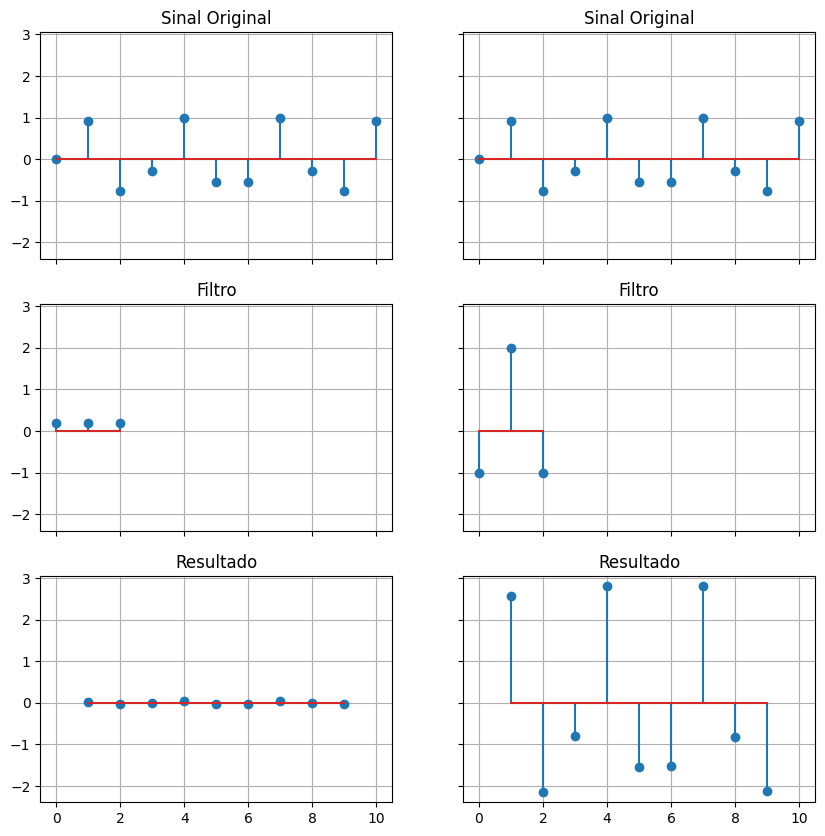

In [53]:
m = np.zeros(11)
for i in range(len(m)):
  m[i] = math.sin(i*2)
h = .2*np.array([1,1,1])
convh=convolucao1D(m,h)
g = [-1,2,-1]
convg=convolucao1D(m,g)

fig, axs = plt.subplots(3,2,figsize=(10,10),sharex=True,sharey=True)

axs[0][0].stem(m)
axs[0][0].set_title("Sinal Original")
axs[0][0].grid()

axs[1][0].stem(h)
axs[1][0].set_title("Filtro")
axs[1][0].grid()

axs[2][0].stem(np.array(range(len(convh))) + 1 ,convh)
axs[2][0].set_title("Resultado")
axs[2][0].grid()

axs[0][1].stem(m)
axs[0][1].set_title("Sinal Original")
axs[0][1].grid()

axs[1][1].stem(g)
axs[1][1].set_title("Filtro")
axs[1][1].grid()

axs[2][1].stem(np.array(range(len(convg))) + 1 ,convg)
axs[2][1].set_title("Resultado")
axs[2][1].grid()

plt.show()


In [55]:
def convolucao2D(m,h):
  res = np.zeros((len(m),len(m[0])-len(h)+1))
  for i in range(len(m)):
    for j in range(len(m[0])-len(h)+1):
      pix = 0
      for x in range(len(h)):
        pix += h[x]*m[i][j+len(h)-x-1]
      res[i][j] = pix
  return res

(np.float64(-0.5), np.float64(317.5), np.float64(210.5), np.float64(-0.5))

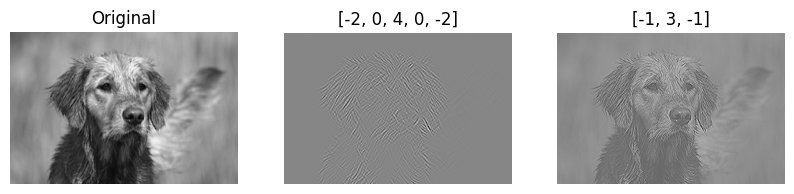

In [57]:
img = carregar_imagem("/content/Adante_Power_of_Gold.jpg") # via Wikimedia Commons
fig, axs = plt.subplots(1,3,figsize=(10,10))

axs[0].imshow(img, cmap="gray")
axs[0].set_title("Original")
axs[0].axis("off")

g = [-2,0,4,0,-2]
h = [-1,3,-1]

convg = convolucao2D(img,g)
convg = convolucao2D(convg.T,g).T

convh = convolucao2D(img,h)
convh = convolucao2D(convh.T,h).T

axs[1].imshow(convg, cmap="gray")
axs[1].set_title(g)
axs[1].axis("off")

axs[2].imshow(convh, cmap="gray")
axs[2].set_title(h)
axs[2].axis("off")